# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [1]:
from astropy import units as u

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [5]:
speed = 60*u.kilometer/u.hour
speed_mps = speed.to(u.meter/u.second)
print(f"60 km / h is {speed_mps:.0f}")

60 km / h is 17 m / s


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [7]:
# Julian dates are a means of recording the years passed since 4173 BC at noon Universal time

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [8]:
# The Gregorian calendar must adjust for the offset in the 365 days per year with a leap 
#year addidive and is measured since 0 AD. The Julian calendar, on the other hand, does 
#not have this adjustment and is instead counting time continuously since 4173 BC. 

From the astropy module `time` import `Time` in the cell below.

In [9]:
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [10]:
time = Time("2025-03-02 16:47:00")
print(f"The Julian Date for March 2nd at 4:47 PM is {time.jd}")

The Julian Date for March 2nd at 4:47 PM is 2460737.199305556


Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [12]:
time_2 = Time("1969-07-02 20:17:00")
print(f"The Julian Date for July 2nd at 8:17 PM is {time_2.jd}")

The Julian Date for July 2nd at 8:17 PM is 2440405.345138889


What historically happened at this date and time?

In [13]:
#Apollo 11 landed on the moon at this time!

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [14]:
from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [15]:
ra = 15*u.degree
dec = -20 *u.degree
frame = 'icrs'

target_icrs = SkyCoord(ra=ra, dec=dec, frame =frame)
print(target_icrs)

<SkyCoord (ICRS): (ra, dec) in deg
    (15., -20.)>


Convert the object's coordinates from ICSRS to **Galactic**.

In [16]:
target_galactic = target_icrs.transform_to(Galactic())
print(target_galactic)

<SkyCoord (Galactic): (l, b) in deg
    (138.76123783, -82.60718782)>


Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [22]:
observing_location = EarthLocation(lat='37.8731', lon='-122.2571')  
observing_time = Time.now()
target_altaz = target_icrs.transform_to(AltAz(location =observing_location,obstime=observing_time))
print(target_altaz)

<SkyCoord (AltAz: obstime=2025-03-03 01:16:20.024740, location=(-2690526.45121845, -4263055.67677888, 3894335.00598486) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    (222.55753104, 19.74680827)>


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [23]:
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [24]:
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [25]:
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [26]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [27]:
with fits.open(image_file) as hdul:
    hdul.info()
    data = hdul[0].data #primary data
    header = hdul[1].header #getting header

Filename: /Users/madelynrahimi/.astropy/cache/download/url/ff6e0b93871033c68022ca026a956d87/contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [30]:
brightest_pixel = np.max(data)
print(brightest_pixel)

22918


With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [31]:
least_brightest_pixel = np.min(data)
print(least_brightest_pixel)

3759


## Tables
From the astropy module `astropy.table` import `Table`.

In [32]:
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [34]:
data = Table({'Star': ["Proxima Centauri", "Barnard's Star", "BL Ceti"],
              'Magnitude': [4.83, 13.2, 15.4],
              'Spectral Type': ["M5.5 V","M4 V","M5.5 V"] })
print(data)

      Star       Magnitude Spectral Type
---------------- --------- -------------
Proxima Centauri      4.83        M5.5 V
  Barnard's Star      13.2          M4 V
         BL Ceti      15.4        M5.5 V


Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [36]:
data.write("data.fits",format='fits')

Read and print the table in the cell below from the `.fits` file you made.

In [40]:
table = Table.read("data.fits")
print(table)

      Star       Magnitude Spectral Type
---------------- --------- -------------
Proxima Centauri      4.83        M5.5 V
  Barnard's Star      13.2          M4 V
         BL Ceti      15.4        M5.5 V


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [41]:
# The HR diagram plots the effective temperature of a star with respect to its luminoscity 
#such that the spectral types of stars can be visualized on a graph

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [42]:
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [63]:
df = pd.read_csv('cluster_data.tsv',skiprows=44, sep=';',header=None,index_col=0,names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'],skipfooter=1,engine='python')



Display the first few rows of the data.

In [64]:
print(df.head())

      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III
13    8.80     3.49   1.128  K0III
14    7.25     5.11   1.200     K0


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [69]:
df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [70]:
df_clean =df_clean.dropna()

Run the cell below. We are converting the datatypes in the columns to floats.

In [71]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
print(df_clean.describe())

                Vmag            Plx            B-V
count  114463.000000  114463.000000  114463.000000
mean        8.297699       7.104872       0.702415
std         1.248614      11.064009       0.490235
min        -1.440000     -35.100000      -0.400000
25%         7.610000       2.520000       0.341000
50%         8.400000       4.580000       0.605000
75%         9.070000       8.260000       1.075000
max        13.610000     772.330000       5.460000


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [73]:
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


/Users/madelynrahimi/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/madelynrahimi/anaconda3/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Describe what the cell above is doing. 

In [74]:
#The cell above transforms given apparent magnitudes and the respective parallaxes
#into absolute magnitudes

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [75]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B5' 'B9' 'M0' 'F8'
 'M1' 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2'
 'A5' 'M4' 'A7' 'O8' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'K8' 'M7'
 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'O5' 'F1' 'K6' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [76]:
# O stars are the hottest stars and M stars are the coldest

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [77]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [78]:
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

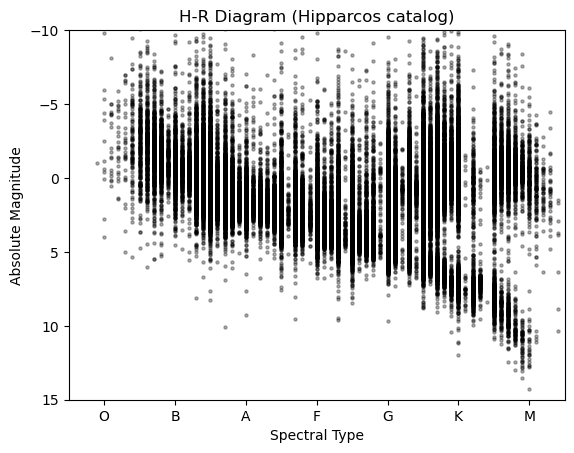

In [83]:
plt.figure()
plt.scatter(df_clean['SpType2_numeric'],df_clean['M_V'],s=5,alpha=0.3,c='k')
plt.xlim(0,70)
plt.ylim(15,-10)
plt.xticks(ticks=range(5,75,10),labels=['O', 'B', 'A', 'F', 'G', 'K', 'M'])
plt.xlabel("Spectral Type")
plt.ylabel("Absolute Magnitude")
plt.title("H-R Diagram (Hipparcos catalog)")
plt.show()

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

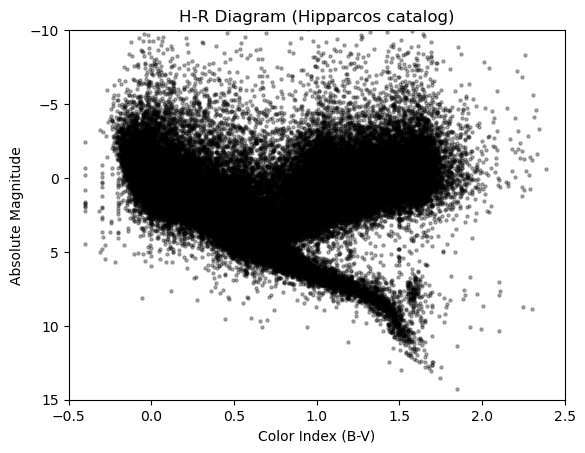

In [84]:
plt.figure()
plt.scatter(df_clean['B-V'],df_clean['M_V'],s=5,alpha=0.3,c='k')
plt.xlim(-0.5,2.5)
plt.ylim(15,-10)
plt.xlabel('Color Index (B-V)')
plt.ylabel("Absolute Magnitude")
plt.title("H-R Diagram (Hipparcos catalog)")
plt.show()

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

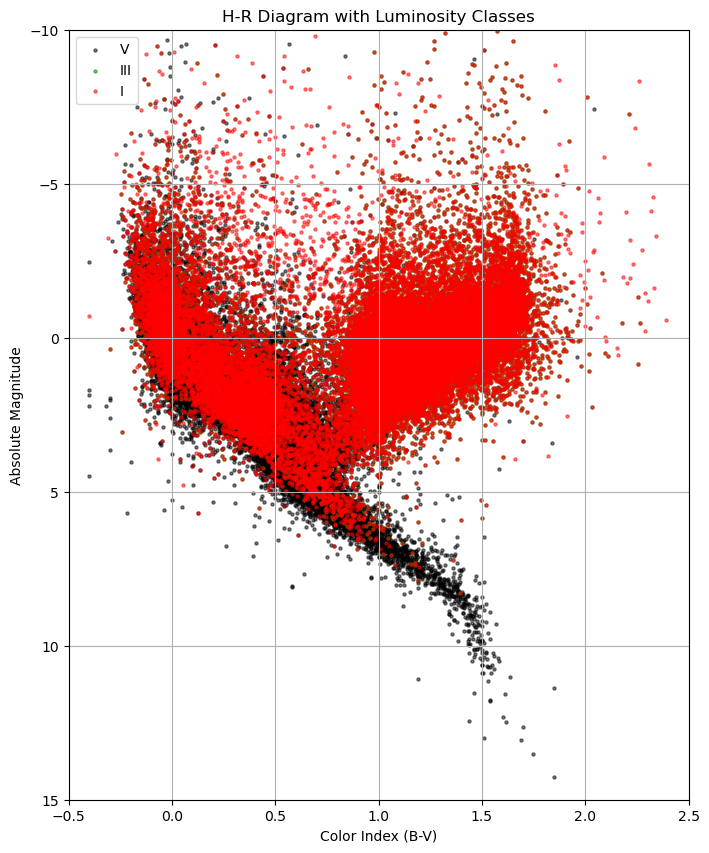

In [85]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()


With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

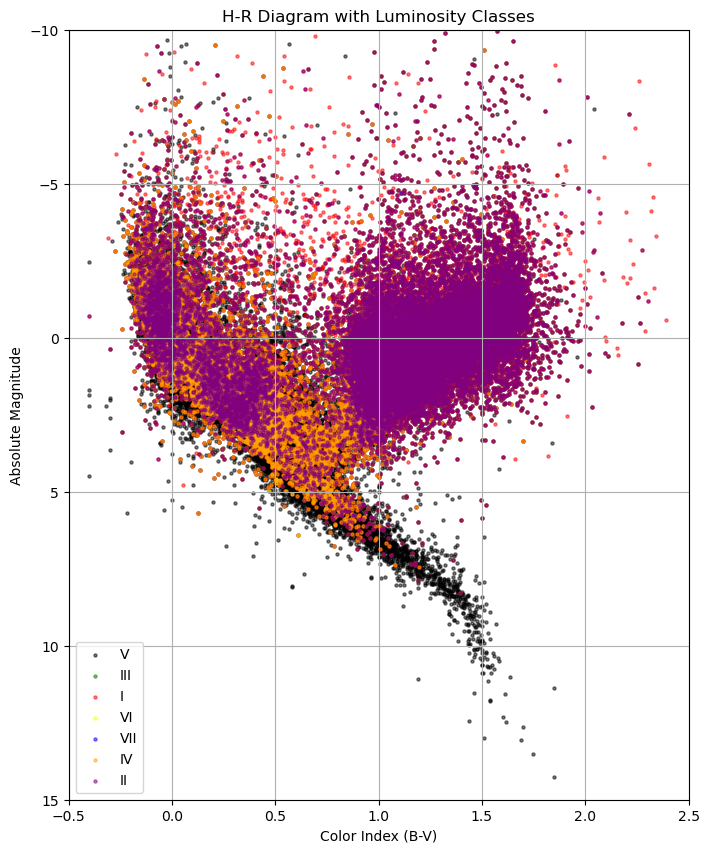

In [86]:
#With types above
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plot_luminosity_class(df_clean, 'VI', 'yellow')  # Subdwarfs
plot_luminosity_class(df_clean, 'VII', 'blue')  # White dwarfs
plot_luminosity_class(df_clean, 'IV', 'orange')  # Subgiants
plot_luminosity_class(df_clean, 'II', 'purple')  # Bright giants

plt.legend()
plt.show()


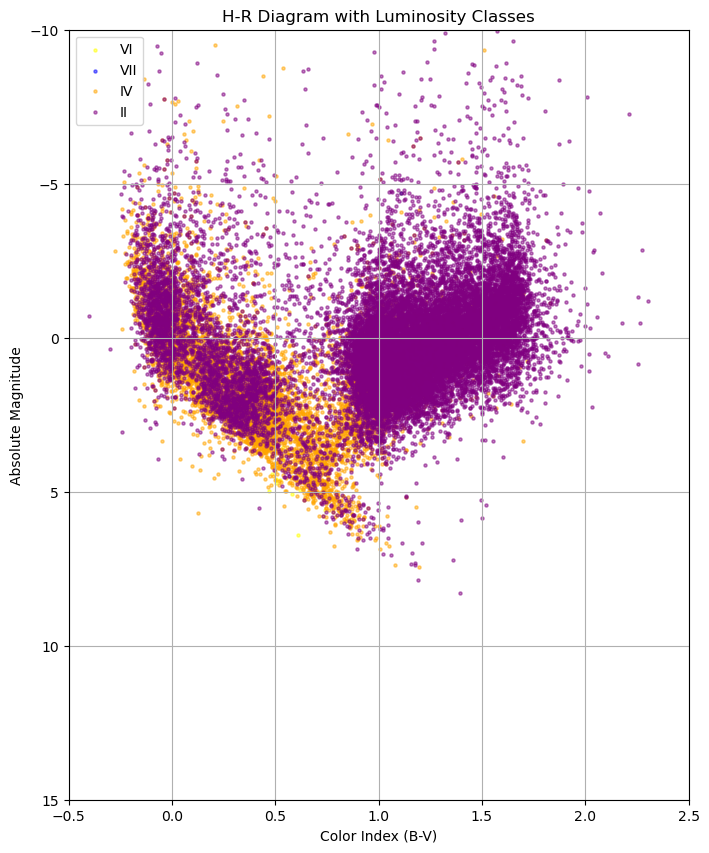

In [88]:
#Without types above
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'VI', 'yellow')  # Subdwarfs
plot_luminosity_class(df_clean, 'VII', 'blue')  # White dwarfs
plot_luminosity_class(df_clean, 'IV', 'orange')  # Subgiants
plot_luminosity_class(df_clean, 'II', 'purple')  # Bright giants

plt.legend()
plt.show()


Submit your FITS file and this notebook to Gradescope!